# 🧠 03 — Entrenamiento del Modelo NER
Entrenamiento del Named Entity Recognizer con spaCy para detectar  
**PRODUCTO**, **CANTIDAD** y **PRECIO** en texto de facturas.

## 1. Configuración

In [2]:
import subprocess
import sys

# Instalar dependencias
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "spacy>=3.6.0"])
print("✅ spacy instalado")

✅ spacy instalado


In [3]:
import sys, os, random
sys.path.insert(0, '..')

import spacy
from spacy.training.example import Example
from spacy.util import minibatch, compounding
import matplotlib.pyplot as plt
import numpy as np

print(f"spaCy version: {spacy.__version__}")


spaCy version: 3.8.14


## 2. Dataset de entrenamiento
Usamos datos sintéticos generados con variedad de formatos +  
ejemplos reales extraídos de la factura ACP36829.

In [4]:
from data.annotations.train_data import TRAIN_DATA

print(f"Total de ejemplos: {len(TRAIN_DATA)}")
print("\n📋 Primeros 5 ejemplos:")
for text, annots in TRAIN_DATA[:5]:
    print(f"  Texto: {repr(text)}")
    print(f"  Entidades: {annots['entities']}")
    print()


Total de ejemplos: 300

📋 Primeros 5 ejemplos:
  Texto: 'CHALECO PROTECTOR FOX CANT: 12 VR: 450000'
  Entidades: [(0, 21, 'PRODUCTO'), (28, 30, 'CANTIDAD'), (35, 41, 'PRECIO')]

  Texto: '14 RODILLERA LEATT P.U. 58000'
  Entidades: [(3, 18, 'PRODUCTO'), (0, 2, 'CANTIDAD'), (24, 29, 'PRECIO')]

  Texto: 'DESCUENTO COMERCIAL x17 $ 62000'
  Entidades: [(0, 19, 'PRODUCTO'), (21, 23, 'CANTIDAD'), (26, 31, 'PRECIO')]

  Texto: 'DESCRIPCION: PROTECTOR ESPALDA LEATT QTY 8 PRECIO: 180000'
  Entidades: [(13, 36, 'PRODUCTO'), (41, 42, 'CANTIDAD'), (51, 57, 'PRECIO')]

  Texto: 'CASCO HAWK HX-W312 x6 $ 218000'
  Entidades: [(0, 18, 'PRODUCTO'), (20, 21, 'CANTIDAD'), (24, 30, 'PRECIO')]



## 3. Análisis del dataset — distribución de etiquetas

In [5]:
from collections import Counter

label_counts = Counter()
for text, annots in TRAIN_DATA:
    for start, end, label in annots['entities']:
        label_counts[label] += 1

print("📊 Distribución de etiquetas:")
for label, count in sorted(label_counts.items()):
    bar = '█' * (count // 3)
    print(f"  {label:10} {count:4} {bar}")

# Verificar balance
total = sum(label_counts.values())
for label, count in label_counts.items():
    print(f"  {label}: {count/total*100:.1f}%")

print(f"\n✅ Dataset balanceado ({total} entidades totales)")


📊 Distribución de etiquetas:
  CANTIDAD    300 ████████████████████████████████████████████████████████████████████████████████████████████████████
  PRECIO      300 ████████████████████████████████████████████████████████████████████████████████████████████████████
  PRODUCTO    300 ████████████████████████████████████████████████████████████████████████████████████████████████████
  PRODUCTO: 33.3%
  CANTIDAD: 33.3%
  PRECIO: 33.3%

✅ Dataset balanceado (900 entidades totales)


## 4. Entrenamiento con seguimiento de loss

In [6]:
# Reproducibilidad
random.seed(42)
np.random.seed(42)

# Separar train / test
random.shuffle(TRAIN_DATA)
split = int(len(TRAIN_DATA) * 0.8)
train_set = TRAIN_DATA[:split]
test_set  = TRAIN_DATA[split:]

print(f"Train: {len(train_set)} | Test: {len(test_set)}")

# Crear modelo
nlp = spacy.blank("es")
ner = nlp.add_pipe("ner", last=True)
for label in ["PRODUCTO", "CANTIDAD", "PRECIO"]:
    ner.add_label(label)

# Entrenamiento con registro de loss
N_ITER = 50
loss_history = []

with nlp.disable_pipes(*[p for p in nlp.pipe_names if p != "ner"]):
    optimizer = nlp.begin_training()
    
    for epoch in range(N_ITER):
        random.shuffle(train_set)
        losses = {}
        batches = minibatch(train_set, size=compounding(4.0, 32.0, 1.001))
        
        for batch in batches:
            examples = []
            for text, annotations in batch:
                doc = nlp.make_doc(text)
                try:
                    examples.append(Example.from_dict(doc, annotations))
                except:
                    pass
            if examples:
                nlp.update(examples, drop=0.3, losses=losses)
        
        ner_loss = losses.get("ner", 0)
        loss_history.append(ner_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"  Época {epoch+1:3}/{N_ITER} — Loss: {ner_loss:.4f}")

print(f"\n✅ Entrenamiento completado. Loss final: {loss_history[-1]:.4f}")

# Guardar modelo
os.makedirs('../models/modelo_facturas', exist_ok=True)
nlp.to_disk('../models/modelo_facturas')
print("✅ Modelo guardado en models/modelo_facturas/")


Train: 240 | Test: 60


c:\Users\User\anaconda3\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "PROTECTOR ESPALDA LEATT x1 $ 229411" with entities "[(0, 23, 'PRODUCTO'), (25, 26, 'CANTIDAD'), (29, 3...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "RODILLERA POD K4 x16 $ 110000" with entities "[(0, 16, 'PRODUCTO'), (18, 20, 'CANTIDAD'), (23, 2...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "CASCO HAWK HX-W

  Época  10/50 — Loss: 1.5359
  Época  20/50 — Loss: 0.0040
  Época  30/50 — Loss: 1.9579
  Época  40/50 — Loss: 0.0000
  Época  50/50 — Loss: 0.0000

✅ Entrenamiento completado. Loss final: 0.0000
✅ Modelo guardado en models/modelo_facturas/


## 5. Curva de aprendizaje

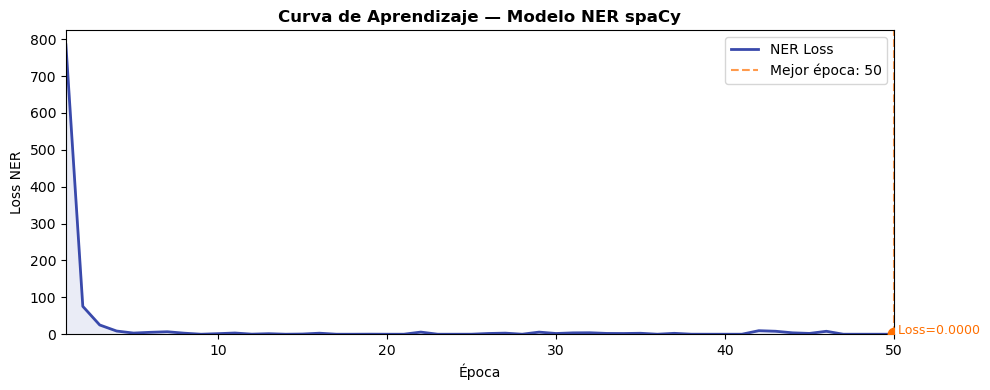

Loss inicial: 784.66 → Loss final: 0.0000


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

epochs = list(range(1, N_ITER + 1))
ax.plot(epochs, loss_history, color='#3949AB', lw=2, label='NER Loss')
ax.fill_between(epochs, loss_history, alpha=0.1, color='#3949AB')

# Marcar mejor epoch
best_epoch = np.argmin(loss_history) + 1
best_loss  = min(loss_history)
ax.axvline(best_epoch, color='#FF6F00', ls='--', alpha=0.7, label=f'Mejor época: {best_epoch}')
ax.scatter([best_epoch], [best_loss], color='#FF6F00', zorder=5, s=80)
ax.annotate(f' Loss={best_loss:.4f}', (best_epoch, best_loss), fontsize=9, color='#FF6F00')

ax.set_xlabel("Época")
ax.set_ylabel("Loss NER")
ax.set_title("Curva de Aprendizaje — Modelo NER spaCy", fontweight='bold')
ax.legend()
ax.set_xlim(1, N_ITER)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('../results/figures/04_curva_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Loss inicial: {loss_history[0]:.2f} → Loss final: {loss_history[-1]:.4f}")


## 6. Prueba rápida del modelo

In [8]:
# Textos de prueba con diferentes formatos
test_texts = [
    "CASCO XTR-902 FLY BLANCO GRIS L 5 218000",
    "GUANTES FOX DIRTPAW 3 UND 58000",
    "DESCRIPCION: RODILLERA POD K4 S CANT 2 PRECIO 95000",
    "2 MALETERO GIVI V35 $180000",
    "SEGURO DE MERCANCIA 1 12605",
]

print("🔍 Predicciones del modelo:\n")
for text in test_texts:
    doc = nlp(text)
    print(f"  Texto: {text}")
    for ent in doc.ents:
        icons = {'PRODUCTO': '🟦', 'CANTIDAD': '🟩', 'PRECIO': '🟨'}
        print(f"    {icons.get(ent.label_, '⬜')} {ent.label_}: '{ent.text}'")
    if not doc.ents:
        print("    ⚠️  No se detectaron entidades")
    print()


🔍 Predicciones del modelo:

  Texto: CASCO XTR-902 FLY BLANCO GRIS L 5 218000
    🟦 PRODUCTO: 'CASCO XTR-902 FLY'
    🟦 PRODUCTO: 'BLANCO GRIS L'
    🟩 CANTIDAD: '5'
    🟨 PRECIO: '218000'

  Texto: GUANTES FOX DIRTPAW 3 UND 58000
    🟦 PRODUCTO: 'GUANTES FOX DIRTPAW'
    🟩 CANTIDAD: '3'
    🟨 PRECIO: '58000'

  Texto: DESCRIPCION: RODILLERA POD K4 S CANT 2 PRECIO 95000
    🟦 PRODUCTO: 'RODILLERA POD K4'
    🟩 CANTIDAD: '2'
    🟨 PRECIO: '95000'

  Texto: 2 MALETERO GIVI V35 $180000
    🟩 CANTIDAD: '2'
    🟦 PRODUCTO: 'MALETERO GIVI V35'
    🟨 PRECIO: '180000'

  Texto: SEGURO DE MERCANCIA 1 12605
    🟦 PRODUCTO: 'SEGURO DE MERCANCIA'
    🟩 CANTIDAD: '1'
    🟨 PRECIO: '12605'

